In [1]:
from google.colab import files
uploaded = files.upload()


Saving customer churn.xlsx to customer churn.xlsx


In [2]:
!pip install openpyxl

In [3]:
import pandas as pd

df = pd.read_excel('customer churn.xlsx')  # Replace with your actual file name
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


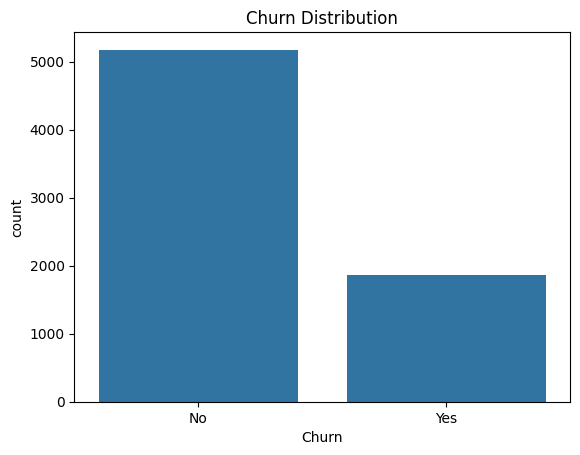

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

In [8]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

customerID: 7043 unique values
gender: 2 unique values
SeniorCitizen: 2 unique values
Partner: 2 unique values
Dependents: 2 unique values
tenure: 73 unique values
PhoneService: 2 unique values
MultipleLines: 3 unique values
InternetService: 3 unique values
OnlineSecurity: 3 unique values
OnlineBackup: 3 unique values
DeviceProtection: 3 unique values
TechSupport: 3 unique values
StreamingTV: 3 unique values
StreamingMovies: 3 unique values
Contract: 3 unique values
PaperlessBilling: 2 unique values
PaymentMethod: 4 unique values
MonthlyCharges: 1585 unique values
TotalCharges: 6531 unique values
Churn: 2 unique values


In [9]:
# Convert TotalCharges to numeric, coerce errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [10]:
# Fill or drop missing values
df = df.dropna()

In [11]:
# Drop irrelevant columns
df.drop(['customerID'], axis=1, inplace=True)

In [12]:
# Encode categorical variables
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Churn')  # Keep target separate

In [13]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler  # ← Add this line

# Then your scaling code
scaler = StandardScaler()
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

In [15]:
df_encoded['Churn'] = df_encoded['Churn'].map({'No':0, 'Yes':1})

In [16]:
print(df_encoded['Churn'].unique())  # Should print [0, 1]

[0 1]


In [17]:
print(df_encoded.head())

   SeniorCitizen    tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0 -1.280248       -1.161694     -0.994194      0        False   
1              0  0.064303       -0.260878     -0.173740      0         True   
2              0 -1.239504       -0.363923     -0.959649      1         True   
3              0  0.512486       -0.747850     -0.195248      0         True   
4              0 -1.239504        0.196178     -0.940457      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1                           False  ...                  

In [18]:
from sklearn.model_selection import train_test_split
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred):.3f}")
    print(f"Recall: {recall_score(y_test, y_pred):.3f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.3f}")
    print(classification_report(y_test, y_pred))
    return model

# Logistic Regression
print("Logistic Regression Performance:")
lr = LogisticRegression(max_iter=1000)
lr_model = evaluate_model(lr, X_train, y_train, X_test, y_test)

Logistic Regression Performance:
Accuracy: 0.805
Precision: 0.650
Recall: 0.575
F1 Score: 0.610
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [21]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
print("Random Forest Performance:")
rf = RandomForestClassifier(random_state=42)
rf_model = evaluate_model(rf, X_train, y_train, X_test, y_test)

Random Forest Performance:
Accuracy: 0.790
Precision: 0.626
Recall: 0.519
F1 Score: 0.567
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [22]:
import xgboost as xgb
print("XGBoost Performance:")
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model = evaluate_model(xgb_model, X_train, y_train, X_test, y_test)

XGBoost Performance:


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:15:30] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.778
Precision: 0.589
Recall: 0.548
F1 Score: 0.568
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1033
           1       0.59      0.55      0.57       374

    accuracy                           0.78      1407
   macro avg       0.71      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407



In [25]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

grid = GridSearchCV(xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
                    param_grid, cv=3, scoring='f1', n_jobs=-1)

grid.fit(X_train, y_train)

print(f"Best params: {grid.best_params_}")

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print(f"Optimized XGBoost F1 Score: {f1_score(y_test, y_pred):.3f}")


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:19:28] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Optimized XGBoost F1 Score: 0.583


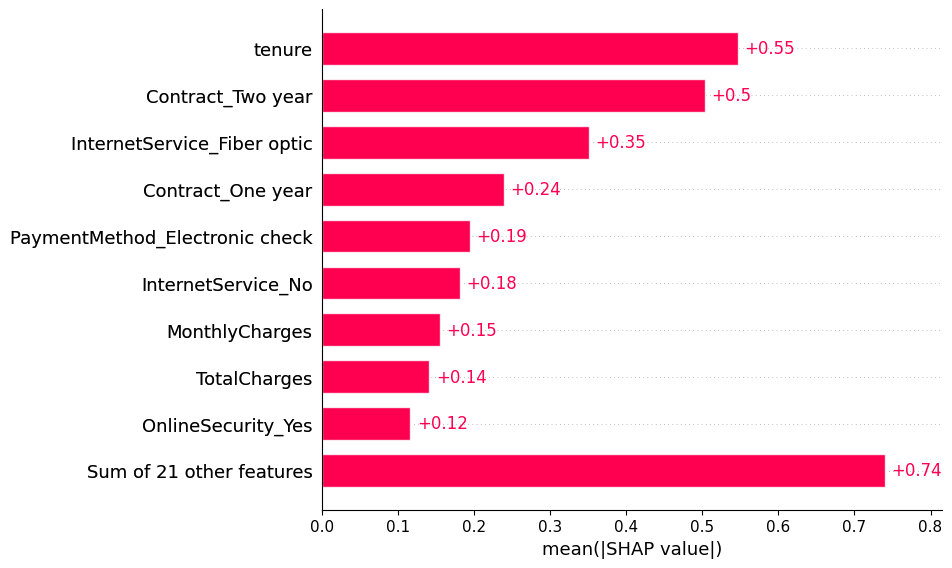

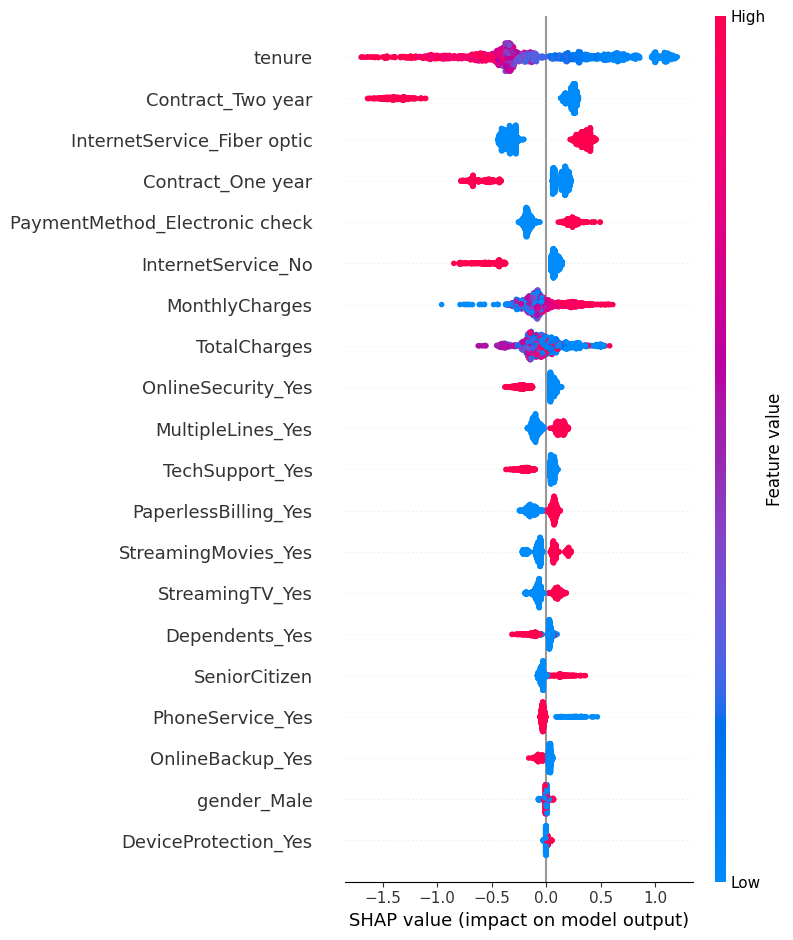

In [30]:
import shap
explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)

# Global feature importance plot
shap.plots.bar(shap_values)

# Detailed summary plot
shap.summary_plot(shap_values, X_test)

In [34]:
# Step 1: Import libraries
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
import joblib

# Step 2: Prepare your data (replace df_encoded with your cleaned dataset)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Step 3: Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 4: Set up XGBoost model and parameter grid
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.1, 0.01, 0.05],
    'n_estimators': [50, 100, 200]
}

# Step 5: GridSearchCV setup
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    scoring='f1',
    verbose=2
)

# Step 6: Fit grid_search to training data
grid_search.fit(X_train, y_train)

# Step 7: Check best parameters and score
print("Best parameters found: ", grid_search.best_params_)
print(f"Best F1 score from CV: {grid_search.best_score_:.3f}")

# Step 8: Extract the best model
best_model = grid_search.best_estimator_

# Step 9: Evaluate on test data
y_pred = best_model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.3f}")

# Step 10: Save the best model
joblib.dump(best_model, 'best_xgb_model.pkl')
print("Model saved as best_xgb_model.pkl")



Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters found:  {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Best F1 score from CV: 0.591
Test Accuracy: 0.796
Model saved as best_xgb_model.pkl


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:35:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [35]:
best_model = grid_search.best_estimator_
import joblib
joblib.dump(best_model, 'best_xgb_model.pkl')


['best_xgb_model.pkl']

In [36]:
from google.colab import files
files.download('best_xgb_model.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

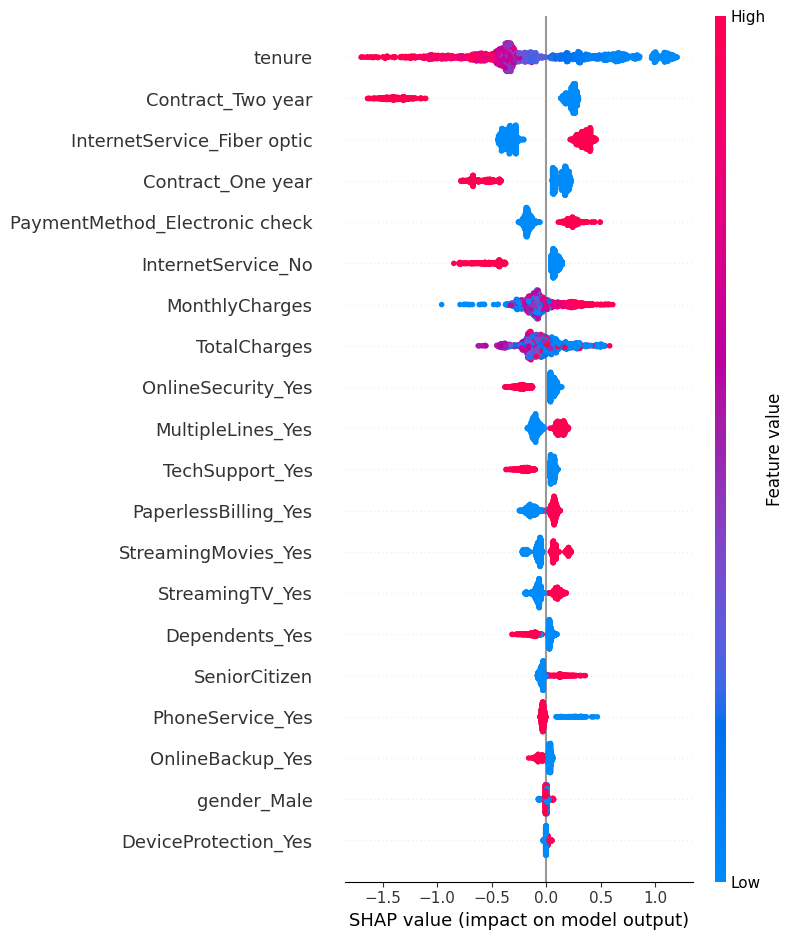

In [37]:
import shap

# Create an explainer object with your best model
explainer = shap.Explainer(best_model)

# Calculate SHAP values for your test dataset
shap_values = explainer(X_test)

# Summary plot showing feature importance and effects
shap.summary_plot(shap_values, X_test)
